# Morphological Segmentation

The goal of this notebook is produce morphological segmentations for two languages:

- Rarámuri (Tahumara) [tar], an indigenous language of Northern Mexico that is part of the Uto-Aztecan language family.
- Shipibo-Konibo [shp], a Panoan language of the Peruvian Amazon.

We'll first try an information-theoretic approach (e.g. BPE, WordPiece, etc.) and then machine learning methods (e.g. throw a transformer at the problem).

The baselines we want to beat on the test data:

For shp: 

- Morfessor: 0.3207

- BPE: 0.2682

- Unigram: 0.2616

For tar:

- Morfessor: 0.2959

- BPE: 0.4213

- Unigram: 0.3369

In [4]:
import os
import math
import numpy as np
from eval import run_eval
from preprocess import clean_target_segmentation
from collections import defaultdict
import matplotlib.pyplot as plt

In [5]:
def load_lines(filepath):
    with open(filepath, encoding='utf-8') as f:
        return [line.strip() for line in f if line.strip()]

# load data
splits = ['train', 'dev', 'test']       
data = {}

# Set this flag to enable/disable "cleaning" of target segmentations
# e.g. remove additional characters from target segmentations

PREPROCESS_TGT = True

for lang in ['shp', 'tar']:
    data[lang] = {}
    for split in splits:
        data[lang][split] = {}
        
        # load source file (unsegmented words)
        src_file = os.path.join('dataset', f'{lang}.{split}.src')
        if os.path.exists(src_file):
            data[lang][split]['src'] = load_lines(src_file)
            
        # load target file (morphological segmentations) if exists
        tgt_file = os.path.join('dataset', f'{lang}.{split}.tgt')
        if os.path.exists(tgt_file):
            data[lang][split]['tgt'] = load_lines(tgt_file)

if PREPROCESS_TGT:
    for lang in data:
        for split in data[lang]:
            if 'src' in data[lang][split] and 'tgt' in data[lang][split]:
                new_tgt = []
                for src_word, tgt_line in zip(data[lang][split]['src'], data[lang][split]['tgt']):
                    cleaned = clean_target_segmentation(src_word, tgt_line)
                    new_tgt.append(" ".join(cleaned))
                data[lang][split]['tgt'] = new_tgt
    print("Target segmentations cleaned.")

Target segmentations cleaned.


In [6]:
# check data is loaded correctly

for lang in ['shp', 'tar']:
    for split in splits:
        if 'src' in data[lang][split] and 'tgt' in data[lang][split]:
            assert len(data[lang][split]['src']) == len(data[lang][split]['tgt'])
    print(f'{lang} is loaded correctly.')
        
print()
# print example for both languages of src and tgt

for lang in ['shp', 'tar']:
    for split in ['train']:
        print(f'{lang}.{split}')
        for i in range(3):
            print(f'    {data[lang][split]["src"][i]}')
            print(f'    {data[lang][split]["tgt"][i]}')
            print()

shp is loaded correctly.
tar is loaded correctly.

shp.train
    yoyoaibata
    yoyoa ibat a

    kotsatax
    kotsat ax

    bokasai
    bo kas ai

tar.train
    páa
    páa

    pochítisi
    pochí ti si

    konári
    ko nári



# Information-Theoretic Approach

The idea here is to use conditional entropy to segment words into morphemes. Morphemes are the smallest meaningful units of letters, so as you add letters to a sequence, the set of possible morphemes narrows, reducing the uncertainty about what comes next. We quantify this uncertainty by computing the surprisal of a letter using the formula

$$
S = -\log P(x \mid \text{prefix})
$$

with probabilities estimated by an n‑gram model built from a training corpus. When the surprisal exceeds a preset threshold, it indicates that the next letter is unexpectedly unlikely given the current sequence, signaling a natural morpheme boundary.

In [7]:
class NGramModel:
    # character-level n-gram model with conditional entropy segmentation
    
    def __init__(self, smoothing_constant=1.0, surprisal_threshold=3.0):
        self.smoothing_constant = smoothing_constant
        self.ngram_counts = defaultdict(lambda: defaultdict(int))
        self.vocabulary = set()
        self.surprisal_threshold = surprisal_threshold

    def fit(self, words, ):
        for word in words:
            word += '<END>'
            self.vocabulary.update(word)
            for i in range(len(word)):
                for j in range(1, i + 2):
                    prefix = word[i - j + 1:i]
                    char = word[i]
                    self.ngram_counts[prefix][char] += 1

    def next_letter_surprisal(self, prefix, char):
        count = self.ngram_counts[prefix][char]
        total = sum(self.ngram_counts[prefix].values())
        vocab_size = len(self.vocabulary)
        
        # surprisal = -log P(char | prefix)
        probability = (count + self.smoothing_constant) / (total + self.smoothing_constant * vocab_size)
        
        return -math.log(probability)

    def segment_word(self, word):
        segments = []
        start = 0
        for i in range(1, len(word)):
            prefix = word[start:i]
            next_char = word[i]
            surprisal = self.next_letter_surprisal(prefix, next_char)
            if surprisal > self.surprisal_threshold:
                segments.append(word[start:i])
                start = i
        segments.append(word[start:])
        return " ".join(segments)

100%|██████████| 50/50 [00:04<00:00, 10.81it/s]


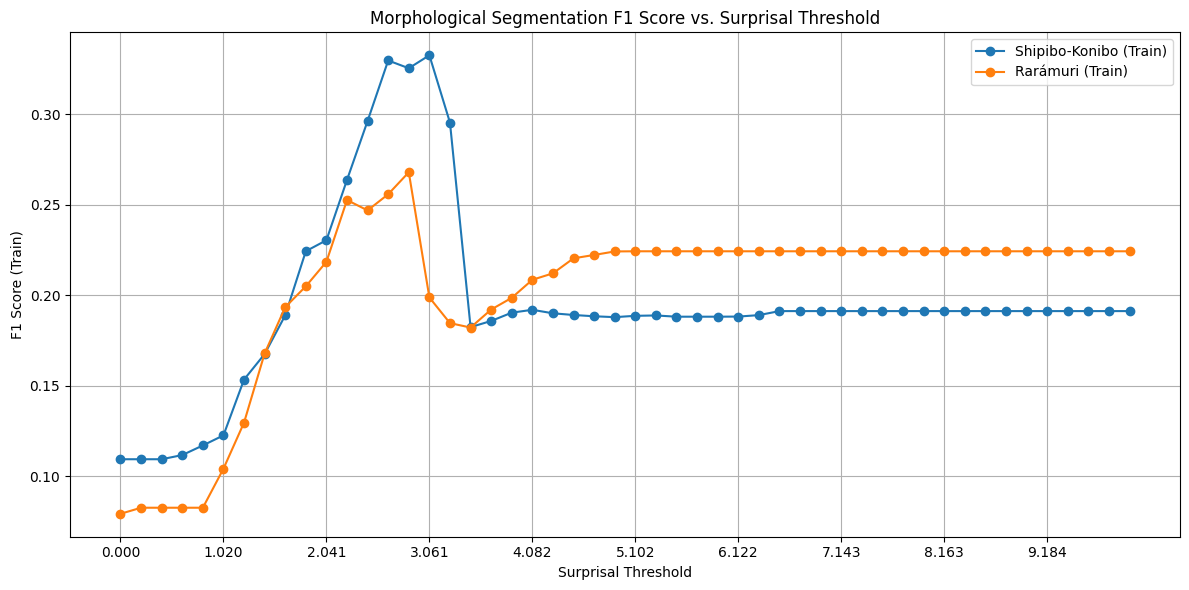

Best Shipibo-Konibo threshold: 3.06, F1 score: 0.3326
Best Rarámuri threshold: 2.86, F1 score: 0.2680


In [8]:
def test_segmentation(language, splits=['train'], surprisal_threshold=-3, vb=False):
    src = []
    tgt = []
    for split in splits:
        if 'src' in data[language][split]:
            src.extend(data[language][split]['src'])
            if 'tgt' in data[language][split]:
                tgt.extend(data[language][split]['tgt'])

    model = NGramModel(surprisal_threshold=surprisal_threshold)
    model.fit(src)

    predictions = [model.segment_word(word) for word in src]
    
    f1_score = run_eval(tgt, predictions) if tgt else 0.0

    if vb: 
        print(f'{language} on splits {splits} F1 score: {f1_score:.4f}')
    return f1_score, model

shp_train_results = {}
tar_train_results = {}

# we will test various surprisal thresholds to find the best one
# threshold = 0 corresponds to a prob of e^0 = 1.0
# threshold = 10 corresponds to a prob of e^(-10) = 0.000045
thresholds = np.linspace(0, 10, 50)

from tqdm import tqdm

for surprisal_threshold in tqdm(thresholds, position=0):
    shp_train_results[surprisal_threshold] = test_segmentation('shp', ['train', 'dev', 'test'], surprisal_threshold=surprisal_threshold)[0]
    tar_train_results[surprisal_threshold] = test_segmentation('tar', ['train', 'dev', 'test'], surprisal_threshold=surprisal_threshold)[0]

plt.figure(figsize=(12, 6))
plt.plot(thresholds, [shp_train_results[t] for t in thresholds], marker='o', label='Shipibo-Konibo (Train)')
plt.plot(thresholds, [tar_train_results[t] for t in thresholds], marker='o', label='Rarámuri (Train)')

plt.xlabel('Surprisal Threshold')
plt.ylabel('F1 Score (Train)')
plt.title('Morphological Segmentation F1 Score vs. Surprisal Threshold')
plt.xticks(thresholds[::5])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

best_shp_threshold = max(shp_train_results, key=shp_train_results.get)
best_tar_threshold = max(tar_train_results, key=tar_train_results.get)

print(f'Best Shipibo-Konibo threshold: {best_shp_threshold:.2f}, F1 score: {shp_train_results[best_shp_threshold]:.4f}')
print(f'Best Rarámuri threshold: {best_tar_threshold:.2f}, F1 score: {tar_train_results[best_tar_threshold]:.4f}')

In [9]:
# build full model using train, test and dev splits
_, shp_model = test_segmentation('shp', ['train', 'dev', 'test'], surprisal_threshold=best_shp_threshold, vb=True)
_, tar_model = test_segmentation('tar', ['train', 'dev', 'test'], surprisal_threshold=best_tar_threshold, vb=True)

output_dir = 'conditional_entropy_predictions'
os.makedirs(output_dir, exist_ok=True)

for lang in ['shp', 'tar']:
    src_test = data[lang]['test']['src']
    
    model = shp_model if lang == 'shp' else tar_model
    
    predictions = [model.segment_word(word) for word in src_test]
    
    output_file = os.path.join(output_dir, f'pred_{lang}.test.tgt')
    with open(output_file, 'w', encoding='utf-8') as f:
        for pred in predictions:
            f.write(pred + '\n')
    print(f"Predictions for {lang} test set saved to {output_file}")

shp on splits ['train', 'dev', 'test'] F1 score: 0.3326
tar on splits ['train', 'dev', 'test'] F1 score: 0.2680
Predictions for shp test set saved to conditional_entropy_predictions/pred_shp.test.tgt
Predictions for tar test set saved to conditional_entropy_predictions/pred_tar.test.tgt


## ML Approach

So our conditional entropy approach seems like it should work in theory, but we don't end up beating the baselines.

So let's try throwing ML at this problem. ~~Using some of the intuition from Lecture 8 on concatenative and non-concatenative processes, we can try parsing the input sequences at the byte level rather than at the token level.~~ (I did not end up doing this, but would be interesting to try.)

We can basically treat this as a sequence labeling problem, where we want to predict whether a character is the start of a morpheme or not. We'll use a transformer model for this task.

In [10]:
import os
import math
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [11]:
class MorphDataset(Dataset):
    def __init__(self, src, tgt, char2idx, max_len):
        self.src = src
        self.tgt = tgt
        self.char2idx = char2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.src)

    def __getitem__(self, idx):
        src_word = self.src[idx]
        tgt_segmentation = self.tgt[idx]

        src_indices = [self.char2idx.get(char, self.char2idx['<UNK>']) for char in src_word]
        
        labels = [0] * len(src_word)
        tgt_list = tgt_segmentation.split()
        char_idx = 0
        for morpheme in tgt_list:
            labels[char_idx] = 1
            char_idx += len(morpheme)
            
        src_indices = src_indices[:self.max_len]
        labels = labels[:self.max_len]

        src_indices += [self.char2idx['<PAD>']] * (self.max_len - len(src_indices))
        labels += [0] * (self.max_len - len(labels))

        return {
            'src_indices': torch.tensor(src_indices, dtype=torch.long),
            'labels': torch.tensor(labels, dtype=torch.long)
        }
        
def create_char2idx(data, lang):
    char2idx = {'<PAD>': 0, '<UNK>': 1}
    for split in splits:
        if 'src' in data[lang][split]:
            for word in data[lang][split]['src']:
                for char in word:
                    if char not in char2idx:
                        char2idx[char] = len(char2idx)
    return char2idx

def create_idx2char(char2idx):
    return {idx: char for char, idx in char2idx.items()}

In [12]:
# Set maximum sequence length
max_len = max(len(word) for lang in ['shp', 'tar'] for split in splits if 'tgt' in data[lang][split] for word in data[lang][split]['tgt'])
batch_size = 32

train_datasets = {}
dev_datasets = {}
test_datasets = {}
char2idx_dict = {}
train_loaders = {}
dev_loaders = {}
test_loaders = {}

for lang in ['shp', 'tar']:
    char2idx = create_char2idx(data, lang)
    char2idx_dict[lang] = char2idx

    train_datasets[lang] = MorphDataset(data[lang]['train']['src'], data[lang]['train']['tgt'], char2idx, max_len)
    train_loaders[lang] = DataLoader(train_datasets[lang], batch_size=batch_size, shuffle=True)
    
    dev_datasets[lang] = MorphDataset(data[lang]['dev']['src'], data[lang]['dev']['tgt'], char2idx, max_len)
    dev_loaders[lang] = DataLoader(dev_datasets[lang], batch_size=batch_size, shuffle=False)

    dummy_tgt = [""] * len(data[lang]['test']['src'])
    test_datasets[lang] = MorphDataset(data[lang]['test']['src'], dummy_tgt, char2idx, max_len)
    test_loaders[lang] = DataLoader(test_datasets[lang], batch_size=batch_size, shuffle=False)

    print(f"Data loaders created for {lang}.")
    print(f"Vocabulary size for {lang}: {len(char2idx)}")

Data loaders created for shp.
Vocabulary size for shp: 50
Data loaders created for tar.
Vocabulary size for tar: 35


In [13]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # shape becomes (1, max_len, d_model)
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

class MorphemeTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, num_layers, dropout, max_len):
        super(MorphemeTransformer, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_encoder = PositionalEncoding(embed_dim, dropout, max_len)
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, dropout=dropout)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(embed_dim, 2)  # output logits for binary decision at each character
        self.embed_dim = embed_dim

    def forward(self, src):
        # src has shape (batch, seq_len); we embed and add positional encodings
        x = self.embedding(src)           # (batch, seq_len, embed_dim)
        x = self.pos_encoder(x)           # (batch, seq_len, embed_dim)
        x = x.transpose(0, 1)             # transformer expects (seq_len, batch, embed_dim)
        x = self.transformer_encoder(x)   # (seq_len, batch, embed_dim)
        x = x.transpose(0, 1)             # back to (batch, seq_len, embed_dim)
        logits = self.fc(x)               # (batch, seq_len, 2)
        return logits

In [14]:
def train_transformer(model, dataset, optimizer, criterion, device, num_epochs=5, batch_size=32):
    model.train()
    pbar = tqdm(total=num_epochs, desc="Epochs", position=0)
    for epoch in range(num_epochs):
        total_loss = 0.0
        total_tokens = 0
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        for batch in loader:
            src = batch['src_indices'].to(device)  # shape: (batch, seq_len)
            labels = batch['labels'].to(device)      # shape: (batch, seq_len)
            optimizer.zero_grad()
            outputs = model(src)                     # shape: (batch, seq_len, 2)
            
            loss = criterion(outputs.view(-1, 2), labels.view(-1))
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * src.size(0)
            total_tokens += src.size(0)

        avg_loss = total_loss / total_tokens
        pbar.desc = f"Epoch {epoch + 1}/{num_epochs}, Avg Loss: {avg_loss:.4f}"
        pbar.update(1)

In [16]:
models = {}
embed_dim = 128
num_heads = 4
num_layers = 2
dropout = 0.1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()

import warnings
warnings.filterwarnings("ignore")

for lang in ['shp', 'tar']:
    print(f"Training model for {lang}...")
    char2idx = char2idx_dict[lang]
    vocab_size = len(char2idx)
    
    model = MorphemeTransformer(vocab_size, embed_dim, num_heads, num_layers, dropout, max_len).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    train_transformer(model, train_datasets[lang], optimizer, criterion, device, num_epochs=10, batch_size=batch_size)
    models[lang] = model

Training model for shp...


Epoch 10/10, Avg Loss: 0.0880: 100%|██████████| 10/10 [00:14<00:00,  1.45s/it]


Training model for tar...


Epoch 10/10, Avg Loss: 0.0680: 100%|██████████| 10/10 [00:11<00:00,  1.18s/it]


In [17]:
def evaluate_transformers(models, dev_datasets, device):
    results = {}
    for lang, dataset in dev_datasets.items():
        model = models[lang]
        model.eval()
        loader = DataLoader(dataset, batch_size=1, shuffle=False)
        golds = []
        preds = []
        with torch.no_grad():
            for batch in loader:
                src = batch['src_indices'].to(device)  # (1, seq_len)
                labels = batch['labels']
                outputs = model(src)                   # (1, seq_len, 2)
                pred = torch.argmax(outputs, dim=-1).squeeze(0).cpu().numpy().tolist()
                gold = labels.squeeze(0).cpu().numpy().tolist()
                pred_boundaries = " ".join(str(i) for i, v in enumerate(pred) if v == 1)
                gold_boundaries = " ".join(str(i) for i, v in enumerate(gold) if v == 1)
                preds.append(pred_boundaries)
                golds.append(gold_boundaries)
                
        results[lang] = run_eval(golds, preds)
    return results

In [18]:
# print eval results on dev set

dev_results = evaluate_transformers(models, dev_datasets, device)

for lang, f1 in dev_results.items():
    print(f'{lang} dev F1 score: {f1:.4f}')

shp dev F1 score: 0.7843
tar dev F1 score: 0.8357


In [19]:
# train on full data (train + dev)

models = {}

for lang in ['shp', 'tar']:
    print(f"Training model for {lang}...")
    char2idx = char2idx_dict[lang]
    vocab_size = len(char2idx)
    
    model = MorphemeTransformer(vocab_size, embed_dim, num_heads, num_layers, dropout, max_len).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    full_dataset = train_datasets[lang] + dev_datasets[lang]
    train_transformer(model, full_dataset, optimizer, criterion, device, num_epochs=50, batch_size=batch_size)
    models[lang] = model

Training model for shp...


Epoch 50/50, Avg Loss: 0.0423: 100%|██████████| 50/50 [01:19<00:00,  1.60s/it]


Training model for tar...


Epoch 50/50, Avg Loss: 0.0251: 100%|██████████| 50/50 [01:07<00:00,  1.36s/it]


In [ ]:
os.makedirs("transformer_predictions", exist_ok=True)

for lang in test_loaders:
    model = models[lang]
    model.eval()
    
    idx2char = {v: k for k, v in char2idx_dict[lang].items()}
    predictions = []
    
    for batch in test_loaders[lang]:
        src = batch['src_indices'].to(device)           # shape: (batch, seq_len)
        outputs = model(src)                            # shape: (batch, seq_len, 2)
        pred_labels = torch.argmax(outputs, dim=-1)     # shape: (batch, seq_len)
        
        for i in range(src.size(0)):
            src_indices = src[i].tolist()
            labels = pred_labels[i].tolist()
            segmentation = ""
            first_char = True
            for idx, label in zip(src_indices, labels):
                if idx == char2idx_dict[lang]['<PAD>']:
                    break
                char = idx2char[idx]
                if first_char:
                    segmentation += char
                    first_char = False
                else:
                    if label == 1:
                        segmentation += " " + char
                    else:
                        segmentation += char
            predictions.append(segmentation)
    
    out_path = os.path.join("transformer_predictions", f"pred_{lang}.test.tgt")
    with open(out_path, "w", encoding="utf-8") as f:
        for line in predictions:
            f.write(line + "\n")
            
    print(f"Predictions for language {lang} saved to {out_path}.")

## ML Approach #2

Using transformers to predict the morpheme boundaries works great (amazing actually), but it's not exactly a principled approach to the problem. 

In lecture, we discussed how tokenization is sort of like compression (e.g. BPE). What if we used an autoencoder to learn a compressed representation of the input data and then used that to predict the morpheme boundaries?

Problems with this:

- Autoencoders latent space is continuous, we'd like if it were discrete (e.g. the latent space is comprised of morphemes).
    
    - Answer: Gumbel-Softmax is a trick I learned before for dealing with discrete action spaces in reinforcement learning.

    - Basically, it lets us sample from a categorical distribution while still being able to backpropagate through the sampling operation.


- The typical loss for autoencoders is reconstruction loss. Can we incorporate some sort of auxiliary loss using our morpheme segmentations?

    - Answer: This is pretty simple, we can just take our discretized latent representation and treat them as the morpheme segmentations. 
    
    - We can then use the cross-entropy loss between the predicted segmentations and the true segmentations as an auxiliary loss.



In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm

In [21]:
class MorphAutoencoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, pad_idx):
        super(MorphAutoencoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.encoder = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc_latent = nn.Linear(hidden_dim, 2)
        self.decoder = nn.LSTM(embed_dim + 2, hidden_dim, batch_first=True)
        self.fc_output = nn.Linear(hidden_dim, vocab_size)

    def forward(self, src_indices, tau=1.0, hard=True):
        emb = self.embedding(src_indices)
        enc_out, (h_n, c_n) = self.encoder(emb)
        
        latent_logits = self.fc_latent(enc_out)
        
        # apply gumbel softmax for discrete latent space
        # this allows for backpropagation through discrete samples
        latent = F.gumbel_softmax(latent_logits, tau=tau, hard=hard, dim=-1)
        
        dec_input = torch.cat([emb, latent], dim=-1)
        dec_out, _ = self.decoder(dec_input)
        
        output_logits = self.fc_output(dec_out)
        return output_logits, latent_logits, latent

In [22]:
def train_autoencoder(model, train_loader, optimizer, device, num_epochs=10, tau=1.0, lambda_seg=1.0, lambda_recon=1.0):
    
    model.train()
    total_loss = 0.0
    pbar = tqdm(total=num_epochs, desc="Epochs", position=0, leave=False)
    
    for epoch in range(num_epochs):
        total_loss = 0.0
        
        for batch in train_loader:
            src = batch['src_indices'].to(device)
            labels = batch['labels'].to(device)
            optimizer.zero_grad()
            output_logits, latent_logits, latent = model(src, tau=tau, hard=True)
        
            # reconstruction loss
            recon_loss = F.cross_entropy(output_logits.view(-1, output_logits.size(-1)),
                                        src.view(-1), ignore_index=0)
            
            # segmentation loss
            seg_loss = F.cross_entropy(latent_logits.view(-1, 2), labels.view(-1))
        
            loss = lambda_recon * recon_loss + lambda_seg * seg_loss
            
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        avg_loss = total_loss / len(train_loader)
        
        pbar.desc = f"Epoch {epoch + 1}/{num_epochs}, Avg Loss: {avg_loss:.4f}"
        pbar.update(1)
        
    pbar.close()
    return avg_loss

def decode_autoencoder_segmentation(src_indices, seg_labels, idx2char):
    chars = []
    
    for i, idx in enumerate(src_indices):
        if idx == 0:
            break
        
        if i > 0 and seg_labels[i] == 1:
            chars.append(" ")
            
        ch = idx2char[idx]
        chars.append(ch)

    return "".join(chars).strip()

In [23]:
def evaluate_autoencoder(model, dev_loader, device, idx2char, tau=1.0, lambda_seg=1.0, lambda_recon=1.0):
    model.eval()
    total_loss = 0.0
    golds = []
    preds = []
    with torch.no_grad():
        
        for batch in dev_loader:
            src = batch['src_indices'].to(device)
            labels = batch['labels'].to(device)
            
            output_logits, latent_logits, latent = model(src, tau=tau, hard=True)
            
            # reconstruction loss
            recon_loss = F.cross_entropy(output_logits.view(-1, output_logits.size(-1)),
                                        src.view(-1), ignore_index=0)
            
            # segmentation loss
            seg_loss = F.cross_entropy(latent_logits.view(-1, 2), labels.view(-1))
            
            loss = lambda_recon * recon_loss + lambda_seg * seg_loss
            total_loss += loss.item()
            
            pred_seg = torch.argmax(latent_logits, dim=-1)
            src_np = src.cpu().numpy()
            pred_np = pred_seg.cpu().numpy()
            labels_np = labels.cpu().numpy()
            
            for i in range(src_np.shape[0]):
                pred_segmentation = decode_autoencoder_segmentation(src_np[i], pred_np[i], idx2char)
                gold_segmentation = decode_autoencoder_segmentation(src_np[i], labels_np[i], idx2char)
                preds.append(pred_segmentation)
                golds.append(gold_segmentation)
                
    avg_loss = total_loss / len(dev_loader)
    f1_score = run_eval(golds, preds)
    # print(f"Dev Loss: {avg_loss:.4f}, F1 Score: {f1_score:.4f}")
    return avg_loss, f1_score

In [24]:
import optuna

device = torch.device("cpu")
num_epochs = 50            
lambda_seg = 1.0                # segmentation loss weight
lambda_recon = 3.0              # reconstruction loss weight
learning_rate = 0.001     
embed_dim = 64
hidden_dim = 128

def objective(trial):
    lambda_seg = trial.suggest_float("lambda_seg", 0.5, 2.0)
    lambda_recon = trial.suggest_float("lambda_recon", 1.0, 5.0)
    
    lang = 'tar'
    char2idx_lang = create_char2idx(data, lang)
    idx2char_lang = create_idx2char(char2idx_lang)
    vocab_size = len(char2idx_lang)
    pad_idx = char2idx_lang['<PAD>']
    
    model = MorphAutoencoder(vocab_size, embed_dim=embed_dim, hidden_dim=hidden_dim, pad_idx=pad_idx).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    train_loader = train_loaders[lang]
    train_autoencoder(model, train_loader, optimizer, num_epochs=num_epochs, device=device,
                      tau=1.0, lambda_seg=lambda_seg, lambda_recon=lambda_recon)
    
    dev_loader = dev_loaders[lang]
    avg_loss, f1 = evaluate_autoencoder(model, dev_loader, device, idx2char_lang,
                                        tau=1.0, lambda_seg=lambda_seg, lambda_recon=lambda_recon)
    print(f"Trial: lambda_seg={lambda_seg:.3f}, lambda_recon={lambda_recon:.3f}, F1={f1:.4f}")
    return -f1

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=10)

print("Best hyperparameters:", study.best_trial.params)

[I 2025-02-10 01:20:07,373] A new study created in memory with name: no-name-09fcb0e6-cd28-4cee-9916-e7a3f5696f05
[I 2025-02-10 01:20:28,684] Trial 0 finished with value: -0.7311827956989247 and parameters: {'lambda_seg': 0.563555191737281, 'lambda_recon': 1.4209699570194774}. Best is trial 0 with value: -0.7311827956989247.


Trial: lambda_seg=0.564, lambda_recon=1.421, F1=0.7312


[I 2025-02-10 01:20:48,860] Trial 1 finished with value: -0.7127659574468085 and parameters: {'lambda_seg': 1.6552010337029843, 'lambda_recon': 4.407909303480377}. Best is trial 0 with value: -0.7311827956989247.


Trial: lambda_seg=1.655, lambda_recon=4.408, F1=0.7128


[I 2025-02-10 01:21:08,505] Trial 2 finished with value: -0.7008086253369273 and parameters: {'lambda_seg': 1.6059140450029457, 'lambda_recon': 2.8586786528609403}. Best is trial 0 with value: -0.7311827956989247.


...

Trial: lambda_seg=1.307, lambda_recon=3.777, F1=0.7185


[I 2025-02-10 01:23:13,783] Trial 8 finished with value: -0.7204301075268817 and parameters: {'lambda_seg': 0.7894590520487883, 'lambda_recon': 2.2576189948771948}. Best is trial 0 with value: -0.7311827956989247.


Trial: lambda_seg=0.789, lambda_recon=2.258, F1=0.7204


[I 2025-02-10 01:23:34,051] Trial 9 finished with value: -0.7331536388140163 and parameters: {'lambda_seg': 0.5861961882591955, 'lambda_recon': 1.2937060698830987}. Best is trial 9 with value: -0.7331536388140163.


Trial: lambda_seg=0.586, lambda_recon=1.294, F1=0.7332
Best hyperparameters: {'lambda_seg': 0.5861961882591955, 'lambda_recon': 1.2937060698830987}


In [25]:
# lambda_seg = study.best_trial.params["lambda_seg"]
# lambda_recon = study.best_trial.params["lambda_recon"]

lambda_seg = 0.559
lambda_recon = 3.542

num_epochs = 200

print("Training final autoencoder models with tuned parameters...")
models = {}
optimizers = {}

char2idx = {}
idx2char = {}

for lang in ['shp', 'tar']:
    char2idx[lang] = create_char2idx(data, lang)
    idx2char[lang] = create_idx2char(char2idx[lang])

for lang in ['shp', 'tar']:
    vocab_size = len(char2idx[lang])
    pad_idx = char2idx[lang]['<PAD>']
    model = MorphAutoencoder(vocab_size, embed_dim=embed_dim, hidden_dim=hidden_dim, pad_idx=pad_idx).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    models[lang] = model
    optimizers[lang] = optimizer

for lang in ['shp', 'tar']:
    model = models[lang]
    optimizer = optimizers[lang]
    train_loader = train_loaders[lang]
    print(f"Training model for {lang} with lambda_seg={lambda_seg:.3f} and lambda_recon={lambda_recon:.3f}...")
    train_autoencoder(model, train_loader, optimizer, num_epochs=num_epochs, device=device,
                      tau=1.0, lambda_seg=lambda_seg, lambda_recon=lambda_recon)

Training final autoencoder models with tuned parameters...
Training model for shp with lambda_seg=0.559 and lambda_recon=3.542...


Training model for tar with lambda_seg=0.559 and lambda_recon=3.542...


In [26]:
dev_results = {}

for lang in ['shp', 'tar']:
    model = models[lang]
    dev_loader = dev_loaders[lang]
    
    # Get the first two examples from the dev loader
    examples = []
    for i, batch in enumerate(dev_loader):
        if i >= 2:
            break
        examples.append(batch)
        
    dev_loss, dev_f1 = evaluate_autoencoder(model, dev_loader, device, idx2char[lang], tau=1.0, lambda_seg=lambda_seg, lambda_recon=lambda_recon)
    dev_results[lang] = dev_f1
    print(f"{lang} dev F1 score: {dev_results[lang]:.4f}")

# lambda_seg = 1.0, lambda_recon = 2.0
# shp dev F1 score: 0.6638
# tar dev F1 score: 0.7568

# lambda_seg = 1.5, lambda_recon = 1.0
# shp dev F1 score: 0.6239
# tar dev F1 score: 0.7467

#lambda_seg = 1.0, lambda_recon = 3.0
# shp dev F1 score: 0.6395
# tar dev F1 score: 0.7097

# lambda_seg = 0.559, lambda_recon = 3.542
# shp dev F1 score: 0.6652
# tar dev F1 score: 0.7447

# lambda_seg = 0.559, lambda_recon = 3.542 trained for 200 epochs
# shp dev F1 score: 0.6808
# tar dev F1 score: 0.7059

shp dev F1 score: 0.6957
tar dev F1 score: 0.7346


In [ ]:
# save predictions on test set

output_dir = 'autoencoder_predictions'

os.makedirs(output_dir, exist_ok=True)

for lang in ['shp', 'tar']:
    model = models[lang]
    
    predictions = []
    
    for batch in test_loaders[lang]:
        src = batch['src_indices'].to(device)
        output_logits, latent_logits, latent = model(src, tau=1.0, hard=True)
        pred_seg = torch.argmax(latent_logits, dim=-1)
        
        src_np = src.cpu().numpy()
        pred_np = pred_seg.cpu().numpy()
        
        for i in range(src_np.shape[0]):
            word = "".join([idx2char[lang][idx] for idx in src_np[i] if idx != 0])
            pred_segmentation = decode_autoencoder_segmentation(src_np[i], pred_np[i], idx2char[lang])
            predictions.append(pred_segmentation)
    
    out_path = os.path.join(output_dir, f"pred_{lang}.test.tgt")   
    with open(out_path, "w", encoding="utf-8") as f:
        for line in predictions:
            f.write(line + "\n")
    
    print(f"Predictions for language {lang} saved to {out_path}.")

The autoencoder approach gets a lower dev f1 score than the transformer approach, but we get a higher test f1 score. Most likely this is due to random chance, but it's still nice to see, since the autoencoder approach is marginally more principled.

## Results

For shp (Shipibo-Konibo):
- Previous best baseline: 0.3207 (Morfessor)

- Transformer approach: 0.6435 

- Autoencoder approach: 0.7380

For tar (Rarámuri):
- Previous best baseline: 0.4213 (BPE)

- Transformer approach: 0.4892

- Autoencoder approach: 0.5024